In [2]:
from numpy import cos, sin, pi
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def A(theta_1, theta_2):
    return cos(theta_1/2)*cos(theta_2/2)

def B(theta_1, theta_2):
    return cos(theta_1/2)*sin(theta_2/2)

def C(theta_1, theta_2):
    return sin(theta_1/2)*cos(theta_2/2)

def D(theta_1, theta_2):
    return sin(theta_1/2)*sin(theta_2/2)

In [8]:
#  Reduced density matrix for qubit 0
def rho_0(theta1, theta2):
    a = A(theta1, theta2)
    b = B(theta1, theta2)
    c = C(theta1, theta2)
    d = D(theta1, theta2)
    
    rho = np.array([
        [a**2 + b**2, a*d + b*c],
        [a*d + b*c, c**2 + d**2]
    ])
    return rho

### Density matrix ρ=∣ψ⟩ ⁣⟨ψ∣ρ=∣ψ⟩⟨ψ

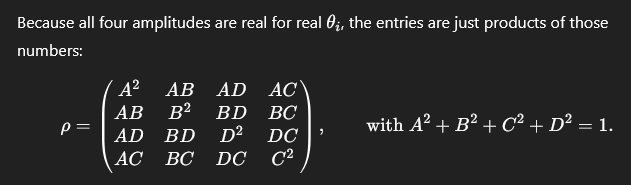

In [3]:
import numpy as np

def state_and_density(theta1, theta2):
    A = np.cos(theta1/2) * np.cos(theta2/2)
    B = np.cos(theta1/2) * np.sin(theta2/2)
    C = np.sin(theta1/2) * np.cos(theta2/2)
    D = np.sin(theta1/2) * np.sin(theta2/2)

    psi = np.array([A, B, D, C], dtype=complex)  # |00>,|01>,|10>,|11>
    rho = np.outer(psi, psi.conj())
    purity = np.trace(rho @ rho).real            # should be 1.0
    return rho, purity


In [4]:
# Reduced density matrix qubit 0
def rho_qubit0(theta1, theta2):
    A = np.cos(theta1/2) * np.cos(theta2/2)
    B = np.cos(theta1/2) * np.sin(theta2/2)
    C = np.sin(theta1/2) * np.cos(theta2/2)
    D = np.sin(theta1/2) * np.sin(theta2/2)

    rho1 = np.array([[A*A + B*B, A*D + B*C],
                     [A*D + B*C, D*D + C*C]], dtype=float)
    purity = np.trace(rho1 @ rho1)        # Tr(ρ₁²) < 1 ⇒ mixed
    return rho1, purity

# Reduced density matrix qubit 1
def rho_qubit1(theta1, theta2):
    A = np.cos(theta1/2) * np.cos(theta2/2)
    B = np.cos(theta1/2) * np.sin(theta2/2)
    C = np.sin(theta1/2) * np.cos(theta2/2)
    D = np.sin(theta1/2) * np.sin(theta2/2)

    rho1 = np.array([[A*A + D*D, A*B + D*C],
                     [A*B + D*C, B*B + C*C]], dtype=float)
    purity = np.trace(rho1 @ rho1)        # Tr(ρ₁²) < 1 ⇒ mixed
    return rho1, purity


In [5]:
# Von Neumann Entropy
def von_neumann_entropy(rho):
    # np.linalg.eigvalsh : Compute the eigenvalues of a complex Hermitian or real symmetric matrix.
    # eigvalsh only returns eigenvalues.
    eigvals = np.linalg.eigvalsh(rho)
    eigvals = eigvals[eigvals > 1e-12]  # Avoid log(0)
    return -np.sum(eigvals * np.log2(eigvals))

In [6]:
# Create grid
theta1_vals = np.linspace(0, np.pi, 100)
theta2_vals = np.linspace(0, np.pi, 100)
T1, T2 = np.meshgrid(theta1_vals, theta2_vals)

In [10]:
# Compute entropy on grid
S = np.zeros_like(T1)
for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        rho = rho_0(T1[i, j], T2[i, j])
        S[i, j] = von_neumann_entropy(rho)

In [10]:
np.max(S)

0.999818408429145

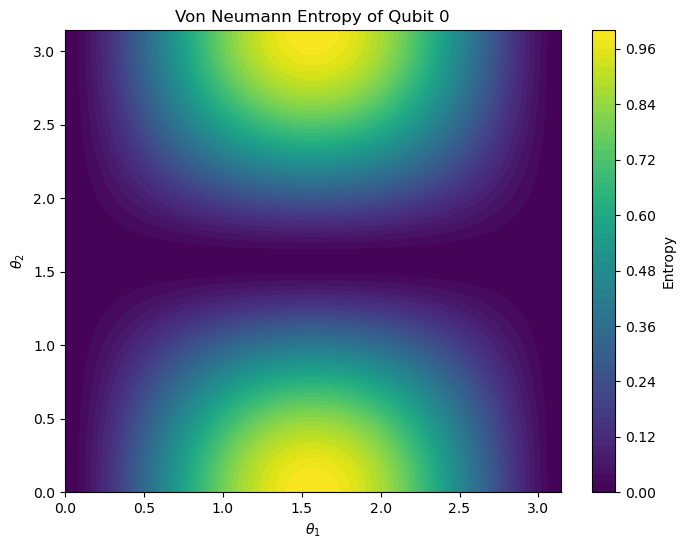

In [7]:
# Plot
fig = plt.figure(figsize=(8, 6))
cp = plt.contourf(T1, T2, S, levels=50)
plt.colorbar(cp, label='Entropy')
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
plt.title('Von Neumann Entropy of Qubit 0')
plt.show()

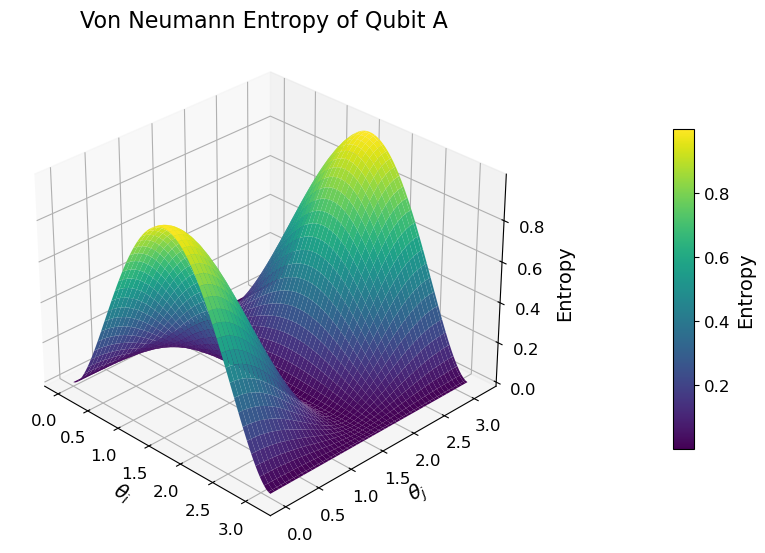

In [11]:
# 3D surface plot
fig = plt.figure(figsize=(12, 8))
# ax = fig.add_subplot(111, projection='3d')
ax = fig.add_axes([0.15, 0.1, 0.65, 0.8], projection='3d')

surf = ax.plot_surface(T1, T2, S, cmap='viridis', edgecolor='none')

ax.set_xlabel(r'$\theta_i$', fontsize=14)
ax.set_ylabel(r'$\theta_j$', fontsize=14)
# Make the Z-label stand out

# ax.set_zlabel('Entropy', fontsize=14) # Add labelpad for Z-axis spacing
ax.zaxis.set_rotate_label(False)            # Keep label upright
ax.set_zlabel('Entropy', fontsize=14, labelpad=5)  # Push label away from axis
ax.zaxis.label.set_rotation(90)             # Optional: set vertical orientation
ax.zaxis.set_label_coords(1.05, 0.5)         # Position to the right of the plot

# Increase font size of tick numbers for all axes
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='z', labelsize=12)
# Alternatively, for all axes: ax.tick_params(labelsize=12)

# Set title with increased font size
ax.set_title('Von Neumann Entropy of Qubit A', fontsize=16, loc="center")

# cbar = fig.colorbar(surf, shrink=0.7, aspect=15, location='left') # Adjust shrink/aspect if needed
cbar = fig.colorbar(surf, shrink=0.5, aspect=15, pad=0.2, location='right')

cbar.set_label('Entropy', fontsize=14) # Increase colorbar label font size
cbar.ax.tick_params(labelsize=12) # Increase colorbar tick numbers font size

# Optional: Adjust view angle for better visualization (if desired)
ax.view_init(elev=30, azim=-45)
fig.subplots_adjust(right=0.88)
figure_name = "Von Neumann Entropy of Qubit A".replace(" ","_") + "General"
plt.savefig(figure_name, dpi=300, bbox_inches='tight')
plt.show()

In [23]:
r = rho_0(1.601, 0)
von_neumann_entropy(r)

0.9993420422119283